# standardize 扫描：50-node ER1 × {standardize=True, False}

本 notebook 是 `test_calm_paper_table7_repro.ipynb` 的姐妹实验。**唯一改动**：
- `graph_config` 固定为 `{d: 50, calm_degree: 1.0, ER}` (50-node ER1)
- 改为扫描 `standardize ∈ {False, True}`，分别给出结果表格
  - `standardize=False` → 对应论文 Table 7
  - `standardize=True`  → 对应论文 Table 5

其他配置 (trials=5, n=20000, noise_ratio=16, 7 个算法, 所有超参) 与 `test_calm_paper_table7_repro.ipynb` 完全一致。

**实现细节**：在 `standardize=True` 时，我们在外部对 X 做标准化后再喂给所有算法；CALM 始终用 `calm_standardize=False`（因为标准化已在外部完成，避免重复）。这样所有算法看到的数据完全对等。

CPDAG-SHD 通过 [`dag_metrics.cpdag_shd`](../../../dag_metrics.py) 计算 (与论文 `causaldag.PDAG.shd` 一致)。

## 1. 环境与导入

In [1]:
import logging
import os
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / 'calm_dataset.py').exists() and (path / 'coordinate_descent').exists():
            return path
    raise RuntimeError(f'Could not find repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate

from calm_dataset import CalmDataset, weight_to_binary_adj
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith

print('Python   :', sys.version.split()[0])
print('Repo root:', REPO_ROOT)
print('cd_A          : OK')
print('cd_A_weakfaith: OK')

c:\Users\super\DAG\experiments\notebooks\test
Python   : 3.10.11
Repo root: C:\Users\super\DAG
cd_A          : OK
cd_A_weakfaith: OK


In [2]:
# ── CALM (kaifeng-jin) ────────────────────────────────────────
CALM_REPO_CANDIDATES = [
    Path(os.environ['CALM_REPO']) if os.environ.get('CALM_REPO') else None,
    REPO_ROOT / 'external' / 'CALM',
    REPO_ROOT.parent / 'CALM',
    Path(r'D:\tmp\CALM-inspect'),
]
CALM_REPO = next(
    (p.resolve() for p in CALM_REPO_CANDIDATES
     if p is not None and (p / 'CALM.py').exists()),
    None,
)
CALM_IMPORT_ERROR = None
try:
    if CALM_REPO is None:
        raise FileNotFoundError('CALM repo not found; set $CALM_REPO or clone to external/CALM')
    if str(CALM_REPO) not in sys.path:
        sys.path.insert(0, str(CALM_REPO))
    import torch
    from CALM import calm as calm_algorithm
    HAS_CALM = True
    print(f'CALM      : OK ({CALM_REPO})')
except Exception as exc:
    HAS_CALM = False
    CALM_IMPORT_ERROR = exc
    print(f'CALM unavailable: {exc}')

# ── GOLEM-NV-l1 ───────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = str((REPO_ROOT / 'golemMain' / 'src').resolve())
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as exc:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = exc
    print(f'GOLEM unavailable: {exc}')

# ── NOTEARS (gcastle) ─────────────────────────────────────────
NOTEARS_IMPORT_ERROR = None
_prev_disable = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    from castle.algorithms import Notears as _Notears
    HAS_NOTEARS = True
    print('NOTEARS   : OK')
except Exception as exc:
    HAS_NOTEARS = False
    NOTEARS_IMPORT_ERROR = exc
    print(f'NOTEARS unavailable: {exc}')
finally:
    logging.disable(_prev_disable)

# ── Tetrad: FGES & PC (需要 JDK 21+) ────────────────────────────
TETRAD_IMPORT_ERROR = None
try:
    import fges_compat as _tetrad_mod
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _tetrad_mod.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_TETRAD = True
    print('Tetrad    : OK (FGES + PC available)')
except Exception as exc:
    HAS_TETRAD = False
    TETRAD_IMPORT_ERROR = exc
    print(f'Tetrad unavailable: {exc}')

CALM      : OK (D:\tmp\CALM-inspect)


GOLEM     : OK
NOTEARS   : OK
Tetrad    : OK (FGES + PC available)


## 2. 实验配置 (固定 50-ER1; standardize 在主循环里扫描)

In [ ]:
CFG = {
    # ── 实验规模 ──────────────────────────────────────────
    'trials': 5,
    'seed':   42,

    # ★ 固定 graph: 50-node ER1
    'graph_config': {'label': '50-node ER1', 'd': 50, 'calm_degree': 1.0, 'graph_type': 'ER'},

    # ★ 扫描维度: 是否做 standardization
    'standardize_modes': [False, True],

    # 样本量 (统一 20000)
    'n_samples': 20000,

    # ── 数据生成 (CalmDataset) ────────────────────────────
    'sem_type':         'gauss',
    'noise_ratio':      16.0,
    'noise_scale_mode': 'variance',
    'b_scale':          1.0,

    # ── CALM ──────────────────────────────────────────────
    # CALM 内部的 standardize 始终设 False; 是否 standardize 由外部统一控制,
    # 保证所有算法看到的 X 完全对等
    'calm_lambda1':         0.005,
    'calm_alpha':           0.01,
    'calm_tau':             0.5,
    'calm_rho_init':        1e-5,
    'calm_rho_mult':        3.0,
    'calm_htol':            1e-8,
    'calm_subproblem_iter': 10000,
    'calm_device':          'cpu',

    # ── GOLEM-NV-l1 (论文默认) ─────────────────────────────
    'golem_equal_variances': False,
    'golem_lambda1':         2e-3,
    'golem_lambda2':         5.0,
    'golem_num_iter':        10000,
    'golem_learning_rate':   1e-3,
    'golem_threshold':       0.3,

    # ── NOTEARS ───────────────────────────────────────────
    'notears_lambda1':   0.1,
    'notears_loss_type': 'l2',
    'notears_threshold': 0.3,
    # ★ runtime tuning: 默认 h_tol=1e-8 + max_iter=100 在稠密图(noise_ratio=16)上极慢
    'notears_h_tol':     1e-4,          # 1e-8 -> 1e-4 (二值图几乎不变,主要 runtime killer)
    'notears_max_iter':  20,            # 100  -> 20  (兜底 AL 外层 iter)

    # ── PC (Tetrad, FisherZ) ───────────────────────────────
    'pc_alpha':  0.01,
    'pc_stable': True,
    'pc_depth':  -1,

    # ── FGES (Tetrad, SEM-BIC) ─────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── cd_A / cd_A_weakfaith ──────────────────────────────
    'cd_T':         1000000,
    'cd_threshold': 0.05,
    'cd_lambda_l0': 0.2,
    'wf_tau':       0.05,
    'wf_screening': 'pcorr',
    'wf_combine':   'union',
    'wf_sampling_mode': 'preserve',

    # ── 输出 ──────────────────────────────────────────────
    'out_dir': str((REPO_ROOT / 'experiments' / 'results').resolve()),
    'tag':     'calm_standardize_sweep',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

ALGORITHM_ORDER = [
    'CALM',
    'GOLEM-NV-l1',
    'NOTEARS',
    'PC',
    'FGES',
    'cd_A',
    'cd_A_weakfaith',
]

_gc = CFG['graph_config']
_s0 = int(round(_gc['calm_degree'] * _gc['d']))
print(f"trials       : {CFG['trials']}")
print(f"n_samples    : {CFG['n_samples']}")
print(f"noise_ratio  : {CFG['noise_ratio']} ({CFG['noise_scale_mode']})")
print(f"graph        : {_gc['label']}  d={_gc['d']}  s0={_s0} edges")
print(f"standardize  : {CFG['standardize_modes']}  (False↔Table 7, True↔Table 5)")
print('algorithms   :', ALGORITHM_ORDER)

trials       : 5
n_samples    : 20000
noise_ratio  : 16.0 (variance)
graph        : 50-node ER1  d=50  s0=50 edges
standardize  : [False, True]  (False↔Table 7, True↔Table 5)
algorithms   : ['CALM', 'GOLEM-NV-l1', 'NOTEARS', 'PC', 'FGES', 'cd_A', 'cd_A_weakfaith']


## 3. 评估函数

全部从 [`dag_metrics`](../../../dag_metrics.py) 导入；CPDAG-SHD 走 `causaldag` 后端，与论文 `compute_shd_cpdag` 一致。

In [4]:
from dag_metrics import (
    cpdag_shd,
    shd_directed,
    skeleton_precision_recall,
    evaluate,
    is_dag as _is_dag_int,
    get_cpdag_shd_backend,
    SHD_SKIP_ALGORITHMS,
)


def tetrad_matrix_to_adj(df_result) -> np.ndarray:
    """Tetrad endpoint matrix -> 0/1 adjacency (ARROW=2, TAIL=3)."""
    mat = df_result.values if hasattr(df_result, 'values') else df_result
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def standardize_X(X: np.ndarray) -> np.ndarray:
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd > 0, sd, 1.0)
    return (X - mu) / sd


def make_dataset(d: int, calm_degree: float, graph_type: str, n: int, seed: int):
    """返回 (X_raw, G_true)。standardize 由外部主循环在调用前统一处理。"""
    ds = CalmDataset(
        n=n, d=d,
        graph_type=graph_type, degree=calm_degree,
        sem_type=CFG['sem_type'],
        seed=int(seed),
        noise_ratio=CFG['noise_ratio'],
        noise_scale_mode=CFG['noise_scale_mode'],
        b_scale=CFG['b_scale'],
    )
    G_true = weight_to_binary_adj(ds.B)
    return ds.X, G_true


print('评估函数已就绪 (从 dag_metrics 导入)')
print(f'  CPDAG-SHD 后端       : {get_cpdag_shd_backend()}')
print(f'  有向 SHD 跳过的算法   : {sorted(SHD_SKIP_ALGORITHMS)}')

C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


评估函数已就绪 (从 dag_metrics 导入)
  CPDAG-SHD 后端       : causaldag
  有向 SHD 跳过的算法   : ['FGES', 'PC']


## 4. 算法封装 (7 个)

所有算法接收同一份 `X` (主循环里根据 `standardize` 模式预处理过)。
CALM 内部的 `standardize` 固定为 False，避免与外部预处理冲突。

In [5]:
def _failure(msg) -> dict:
    return {'status': 'failed', 'G_est': None, 'message': str(msg)}


def _sample_cov(X: np.ndarray) -> np.ndarray:
    Xc = X - X.mean(axis=0, keepdims=True)
    return Xc.T @ Xc / Xc.shape[0]


def run_CALM(X, seed):
    if not HAS_CALM:
        return _failure(f'CALM unavailable: {CALM_IMPORT_ERROR}')
    np.random.seed(seed)
    torch.manual_seed(seed)
    B_w = calm_algorithm(
        X,
        lambda1=CFG['calm_lambda1'],
        alpha=CFG['calm_alpha'],
        tau=CFG['calm_tau'],
        rho_init=CFG['calm_rho_init'],
        rho_mult=CFG['calm_rho_mult'],
        htol=CFG['calm_htol'],
        subproblem_iter=CFG['calm_subproblem_iter'],
        standardize=False,   # 主循环已在外部按 standardize 模式预处理
        device=CFG['calm_device'],
    )
    G_est = (np.abs(np.asarray(B_w)) > 0).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_GOLEM_NV_l1(X, seed):
    if not HAS_GOLEM:
        return _failure(f'GOLEM unavailable: {GOLEM_IMPORT_ERROR}')
    B_est = golem_fit(
        X,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
        num_iter=CFG['golem_num_iter'],
        learning_rate=CFG['golem_learning_rate'],
        seed=int(seed),
    )
    G_est = (np.abs(np.asarray(B_est)) > CFG['golem_threshold']).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_NOTEARS(X, seed):
    if not HAS_NOTEARS:
        return _failure(f'NOTEARS unavailable: {NOTEARS_IMPORT_ERROR}')
    model = _Notears(
        lambda1=CFG['notears_lambda1'],
        loss_type=CFG['notears_loss_type'],
        w_threshold=CFG['notears_threshold'],
        h_tol=CFG['notears_h_tol'],
        max_iter=CFG['notears_max_iter'],
    )
    _prev = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        model.learn(X)
    finally:
        logging.disable(_prev)
    G_est = np.asarray(model.causal_matrix, dtype=int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_PC(X, seed):
    if not HAS_TETRAD:
        return _failure(f'Tetrad unavailable: {TETRAD_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.run_pc(
        alpha=CFG['pc_alpha'],
        stable=CFG['pc_stable'],
        depth=CFG['pc_depth'],
    )
    G_est = tetrad_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_FGES(X, seed):
    if not HAS_TETRAD:
        return _failure(f'Tetrad unavailable: {TETRAD_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
    search.run_fges()
    G_est = tetrad_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A(X, seed):
    S = _sample_cov(X)
    A, G_est, obj = dag_coordinate_descent_l0(
        S=S, T=CFG['cd_T'], seed=int(seed),
        threshold=CFG['cd_threshold'], lambda_l0=CFG['cd_lambda_l0'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A_weakfaith(X, seed):
    S = _sample_cov(X)
    A, G_est, obj = dag_coordinate_descent_l0_weakfaith(
        S=S, T=CFG['cd_T'], seed=int(seed),
        threshold=CFG['cd_threshold'], lambda_l0=CFG['cd_lambda_l0'],
        faithfulness_tau=CFG['wf_tau'],
        screening=CFG['wf_screening'],
        combine=CFG['wf_combine'],
        sampling_mode=CFG['wf_sampling_mode'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


RUNNERS = {
    'CALM':           run_CALM,
    'GOLEM-NV-l1':    run_GOLEM_NV_l1,
    'NOTEARS':        run_NOTEARS,
    'PC':             run_PC,
    'FGES':           run_FGES,
    'cd_A':           run_cd_A,
    'cd_A_weakfaith': run_cd_A_weakfaith,
}
RUNNERS = {k: RUNNERS[k] for k in ALGORITHM_ORDER if k in RUNNERS}
list(RUNNERS)

['CALM', 'GOLEM-NV-l1', 'NOTEARS', 'PC', 'FGES', 'cd_A', 'cd_A_weakfaith']

## 5. 主循环 (或加载已保存结果)

外层 `standardize × trial × algorithm`。同一 (standardize, trial) 内所有算法共享同一份预处理后的样本。

**两种运行模式**（cell 顶部 `RUN_FROM_SCRATCH` 开关）：
- `RUN_FROM_SCRATCH = True` （默认）：执行完整主循环，结果写入 CSV。
- `RUN_FROM_SCRATCH = False`：跳过算法运行，从 `experiments/results/` 读取上一次的 trials CSV，下游 cell 直接渲染表格。

In [6]:
RUN_FROM_SCRATCH = True
SAVED_TRIALS_CSV = None   # None -> 自动选最新匹配 CFG['tag'] 的 trials csv


def _load_latest_trials_csv() -> str:
    import glob
    pattern = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_*.csv")
    candidates = sorted(glob.glob(pattern))
    if not candidates:
        raise FileNotFoundError(
            f"找不到匹配 {pattern} 的历史 trials CSV; "
            f"请把 RUN_FROM_SCRATCH 改回 True 重新跑实验。"
        )
    return candidates[-1]


if not RUN_FROM_SCRATCH:
    csv_path = SAVED_TRIALS_CSV or _load_latest_trials_csv()
    df_trials = pd.read_csv(csv_path)
    if 'shd' not in df_trials.columns:
        df_trials['shd'] = np.nan
    skip_logs = df_trials[df_trials['status'] != 'ok'].to_dict(orient='records')
    print(f'✓ 已加载历史 trials -> {csv_path}')
    print(f'  rows         : {len(df_trials)}')
    print(f"  standardize  : {sorted(df_trials['standardize'].unique().tolist())}")
    print(f"  algorithms   : {sorted(df_trials['algorithm'].unique().tolist())}")
    display(df_trials.head(20))

else:
    rng = np.random.default_rng(CFG['seed'])
    rows = []
    skip_logs = []

    _gc = CFG['graph_config']
    label, d, calm_degree, graph_type = _gc['label'], _gc['d'], _gc['calm_degree'], _gc['graph_type']
    n_samples = CFG['n_samples']

    for standardize in CFG['standardize_modes']:
        # ★ 每个 standardize 模式重置 RNG，确保两组 trial 用同一批 seed (同样的真实图与原始 X)
        # 这样 standardize=True/False 之间的差异完全来自预处理，与底层数据无关。
        rng_for_mode = np.random.default_rng(CFG['seed'])
        trial_seeds = rng_for_mode.integers(0, 10**9, size=CFG['trials'])

        for trial_id, data_seed_raw in enumerate(trial_seeds, start=1):
            data_seed = int(data_seed_raw)
            X_raw, G_true = make_dataset(d, calm_degree, graph_type, n_samples, data_seed)
            X = standardize_X(X_raw) if standardize else X_raw
            n_edges_true = int(G_true.sum())

            for alg_idx, (alg_name, runner) in enumerate(RUNNERS.items()):
                alg_seed = data_seed + 1009 * (alg_idx + 1)
                t0 = time.perf_counter()
                try:
                    result = runner(X, alg_seed)
                except Exception as exc:
                    result = _failure(exc)
                runtime_sec = time.perf_counter() - t0

                base = {
                    'graph_label':  label,
                    'd':            d,
                    'calm_degree':  calm_degree,
                    'standardize':  bool(standardize),
                    'n_samples':    n_samples,
                    'trial_id':     trial_id,
                    'data_seed':    data_seed,
                    'algorithm':    alg_name,
                    'status':       result['status'],
                    'n_edges_true': n_edges_true,
                    'runtime_sec':  float(runtime_sec),
                    'message':      result.get('message', ''),
                }
                if result['status'] == 'ok':
                    metrics = evaluate(G_true, result['G_est'], algorithm=alg_name)
                    row = {**base, **metrics}
                    shd_str = f"{row['shd']:6.1f}" if not pd.isna(row['shd']) else '   n/a'
                    print(
                        f'[std={str(standardize):5s} | {alg_name:15s}] '
                        f"trial={trial_id} "
                        f"cpdag_shd={row['cpdag_shd']:6.1f} shd={shd_str} "
                        f"sk_p={row['sk_p']:.3f} sk_r={row['sk_r']:.3f} "
                        f"rt={runtime_sec:6.2f}s"
                    )
                else:
                    row = {**base, 'cpdag_shd': np.nan, 'shd': np.nan,
                           'sk_p': np.nan, 'sk_r': np.nan, 'n_edges_est': np.nan}
                    skip_logs.append(base)
                    print(f'[SKIP std={standardize} | {alg_name}] {result["message"]}')
                rows.append(row)

    df_trials = pd.DataFrame(rows)
    display(df_trials.head(20))
    print(f'\ntotal rows: {len(df_trials)}')

[std=False | CALM           ] trial=1 cpdag_shd=  20.0 shd=  21.0 sk_p=0.893 sk_r=1.000 rt=2447.75s



2026-05-10 21:40:58,548 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From C:\Users\super\DAG\golemMain\src\models\golem_model.py:71: The name tf.train.AdamOptimizer is deprecated. Please use tf.compat.v1.train.AdamOptimizer instead.

2026-05-10 21:40:58,995 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[std=False | GOLEM-NV-l1    ] trial=1 cpdag_shd=  65.0 shd=  69.0 sk_p=0.489 sk_r=0.440 rt= 56.92s
[std=False | NOTEARS        ] trial=1 cpdag_shd=   3.0 shd=   4.0 sk_p=0.980 sk_r=1.000 rt=667.80s
[std=False | PC             ] trial=1 cpdag_shd=   1.0 shd=   n/a sk_p=1.000 sk_r=0.980 rt=  7.85s
[std=False | FGES           ] trial=1 cpdag_shd=   6.0 shd=   n/a sk_p=0.909 sk_r=1.000 rt=  4.30s
[std=False | cd_A           ] trial=1 cpdag_shd=  38.0 shd=  41.0 sk_p=0.683 sk_r=0.820 rt=671.95s
[std=False | cd_A_weakfaith ] trial=1 cpdag_shd=   9.0 shd=   9.0 sk_p=0.980 sk_r=0.980 rt=675.23s
[std=False | CALM           ] trial=2 cpdag_shd=  10.0 shd=  16.0 sk_p=0.909 sk_r=1.000 rt=2052.82s


2026-05-10 22:49:55,522 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[std=False | GOLEM-NV-l1    ] trial=2 cpdag_shd=  71.0 shd=  71.0 sk_p=0.426 sk_r=0.400 rt= 54.26s
[std=False | NOTEARS        ] trial=2 cpdag_shd=  13.0 shd=  13.0 sk_p=0.860 sk_r=0.980 rt=179.63s
[std=False | PC             ] trial=2 cpdag_shd=   1.0 shd=   n/a sk_p=0.980 sk_r=1.000 rt=  4.35s
[std=False | FGES           ] trial=2 cpdag_shd=   5.0 shd=   n/a sk_p=0.943 sk_r=1.000 rt=  4.14s
[std=False | cd_A           ] trial=2 cpdag_shd=  34.0 shd=  34.0 sk_p=0.720 sk_r=0.720 rt=678.71s
[std=False | cd_A_weakfaith ] trial=2 cpdag_shd=  13.0 shd=  12.0 sk_p=0.956 sk_r=0.860 rt=654.64s
[std=False | CALM           ] trial=3 cpdag_shd=   9.0 shd=  16.0 sk_p=0.960 sk_r=0.960 rt=2015.11s


...

[std=True  | GOLEM-NV-l1    ] trial=4 cpdag_shd=  71.0 shd=  67.0 sk_p=0.484 sk_r=0.620 rt= 53.85s
[std=True  | NOTEARS        ] trial=4 cpdag_shd=  40.0 shd=  37.0 sk_p=0.841 sk_r=0.740 rt=378.62s
[std=True  | PC             ] trial=4 cpdag_shd=   7.0 shd=   n/a sk_p=0.980 sk_r=0.980 rt=  3.92s
[std=True  | FGES           ] trial=4 cpdag_shd=   6.0 shd=   n/a sk_p=0.943 sk_r=1.000 rt=  3.91s
[std=True  | cd_A           ] trial=4 cpdag_shd=  63.0 shd=  59.0 sk_p=0.544 sk_r=0.620 rt=649.95s
[std=True  | cd_A_weakfaith ] trial=4 cpdag_shd=  38.0 shd=  31.0 sk_p=0.848 sk_r=0.780 rt=649.01s
[std=True  | CALM           ] trial=5 cpdag_shd=   0.0 shd=   3.0 sk_p=1.000 sk_r=1.000 rt=1458.34s


2026-05-11 06:35:46,940 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[std=True  | GOLEM-NV-l1    ] trial=5 cpdag_shd=  60.0 shd=  62.0 sk_p=0.547 sk_r=0.700 rt= 56.31s
[std=True  | NOTEARS        ] trial=5 cpdag_shd=  45.0 shd=  36.0 sk_p=0.812 sk_r=0.780 rt=667.03s
[std=True  | PC             ] trial=5 cpdag_shd=   2.0 shd=   n/a sk_p=0.980 sk_r=1.000 rt=  4.16s
[std=True  | FGES           ] trial=5 cpdag_shd=   2.0 shd=   n/a sk_p=0.980 sk_r=1.000 rt=  4.16s
[std=True  | cd_A           ] trial=5 cpdag_shd=  39.0 shd=  43.0 sk_p=0.700 sk_r=0.700 rt=661.34s
[std=True  | cd_A_weakfaith ] trial=5 cpdag_shd=  13.0 shd=  15.0 sk_p=0.957 sk_r=0.880 rt=649.20s


,graph_label,d,calm_degree,standardize,n_samples,trial_id,data_seed,algorithm,status,n_edges_true,runtime_sec,message,cpdag_shd,shd,sk_p,sk_r,n_edges_est
0,50-node ER1,50,1.0,False,20000,1,89250953,CALM,ok,50,2447.750527,,20.0,21.0,0.892857,1.00,56
1,50-node ER1,50,1.0,False,20000,1,89250953,GOLEM-NV-l1,ok,50,56.918387,,65.0,69.0,0.488889,0.44,45
2,50-node ER1,50,1.0,False,20000,1,89250953,NOTEARS,ok,50,667.796364,,3.0,4.0,0.980392,1.00,51
3,50-node ER1,50,1.0,False,20000,1,89250953,PC,ok,50,7.847394,,1.0,NaN,1.000000,0.98,62
4,50-node ER1,50,1.0,False,20000,1,89250953,FGES,ok,50,4.299422,,6.0,NaN,0.909091,1.00,68
5,50-node ER1,50,1.0,False,20000,1,89250953,cd_A,ok,50,671.952669,,38.0,41.0,0.683333,0.82,60
6,50-node ER1,50,1.0,False,20000,1,89250953,cd_A_weakfaith,ok,50,675.228370,,9.0,9.0,0.980000,0.98,50
7,50-node ER1,50,1.0,False,20000,2,773956048,CALM,ok,50,2052.820910,,10.0,16.0,0.909091,1.00,55
8,50-node ER1,50,1.0,False,20000,2,773956048,GOLEM-NV-l1,ok,50,54.260385,,71.0,71.0,0.425532,0.40,47
9,50-node ER1,50,1.0,False,20000,2,773956048,NOTEARS,ok,50,179.625405,,13.0,13.0,0.859649,0.98,57



total rows: 70


## 6. 汇总：mean ± std

In [7]:
ok = df_trials[df_trials['status'] == 'ok'].copy()
if ok.empty:
    raise RuntimeError('No successful runs.')

df_summary = (
    ok.groupby(['standardize', 'algorithm'], as_index=False)
      .agg(
          trials       = ('trial_id',    'count'),
          cpdag_shd_mean = ('cpdag_shd', 'mean'),
          cpdag_shd_std  = ('cpdag_shd', 'std'),
          shd_mean       = ('shd',       'mean'),   # PC/FGES 上为 NaN
          shd_std        = ('shd',       'std'),
          sk_p_mean      = ('sk_p',      'mean'),
          sk_p_std       = ('sk_p',      'std'),
          sk_r_mean      = ('sk_r',      'mean'),
          sk_r_std       = ('sk_r',      'std'),
          n_edges_est_mean = ('n_edges_est', 'mean'),
          n_edges_true_mean= ('n_edges_true','mean'),
          runtime_sec_mean = ('runtime_sec', 'mean'),
      )
)
df_summary['algorithm'] = pd.Categorical(df_summary['algorithm'], categories=ALGORITHM_ORDER, ordered=True)
df_summary = df_summary.sort_values(['standardize', 'algorithm']).reset_index(drop=True)
display(df_summary)

_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts}.csv")
_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts}.csv")
df_trials.to_csv(_trials_path, index=False)
df_summary.to_csv(_summary_path, index=False)
print(f'\nsaved trials  -> {_trials_path}')
print(f'saved summary -> {_summary_path}')

,standardize,algorithm,trials,cpdag_shd_mean,cpdag_shd_std,shd_mean,shd_std,sk_p_mean,sk_p_std,sk_r_mean,sk_r_std,n_edges_est_mean,n_edges_true_mean,runtime_sec_mean
0,False,CALM,5,11.6,6.580274,16.4,5.319774,0.926246,0.041460,0.984,0.021909,53.2,50.0,1977.258935
1,False,GOLEM-NV-l1,5,71.4,4.774935,73.2,3.193744,0.454265,0.029583,0.448,0.030332,49.4,50.0,55.152199
2,False,NOTEARS,5,8.4,3.974921,7.8,3.701351,0.927040,0.047187,0.992,0.010954,53.6,50.0,492.559378
3,False,PC,5,2.6,2.509980,NaN,NaN,0.988157,0.010812,0.984,0.016733,65.0,50.0,4.855924
4,False,FGES,5,4.2,2.049390,NaN,NaN,0.947563,0.026400,1.000,0.000000,65.6,50.0,4.085122
5,False,cd_A,5,35.6,4.393177,37.8,3.563706,0.702009,0.017479,0.788,0.041473,56.2,50.0,665.183568
6,False,cd_A_weakfaith,5,13.2,3.033150,12.4,3.911521,0.950687,0.022784,0.924,0.047749,48.6,50.0,650.001784
7,True,CALM,5,4.6,4.722288,8.6,4.335897,0.976905,0.024662,0.992,0.017889,50.8,50.0,1614.742011
8,True,GOLEM-NV-l1,5,61.0,7.778175,61.6,5.366563,0.536964,0.046042,0.648,0.059330,60.4,50.0,54.646026
9,True,NOTEARS,5,42.2,5.805170,38.2,6.099180,0.811091,0.046920,0.736,0.045607,45.4,50.0,481.126584



saved trials  -> C:\Users\super\DAG\experiments\results\calm_standardize_sweep_trials_20260511_070948.csv
saved summary -> C:\Users\super\DAG\experiments\results\calm_standardize_sweep_summary_20260511_070948.csv


## 7. 论文表格风格 (mean ± std) ：每个 standardize 模式一张表

- `standardize=False` 对应 paper Table 7
- `standardize=True`  对应 paper Table 5

In [8]:
def _fmt(mu, sd, p=1):
    if pd.isna(mu):
        return 'n/a'
    if pd.isna(sd):
        sd = 0.0
    return f'{mu:.{p}f} ± {sd:.{p}f}'


tables = {}
for standardize in CFG['standardize_modes']:
    sub = df_summary[df_summary['standardize'] == standardize]
    rows_paper = []
    for alg in ALGORITHM_ORDER:
        s = sub[sub['algorithm'] == alg]
        if s.empty:
            rows_paper.append({
                'algorithm': alg,
                'SHD of CPDAG':         'n/a',
                'Precision of Skeleton': 'n/a',
                'Recall of Skeleton':    'n/a',
                'SHD':                   'n/a',
            })
            continue
        row = s.iloc[0]
        if alg in SHD_SKIP_ALGORITHMS:
            shd_cell = '-'
        else:
            shd_cell = _fmt(row['shd_mean'], row['shd_std'], p=1)
        rows_paper.append({
            'algorithm': alg,
            'SHD of CPDAG':         _fmt(row['cpdag_shd_mean'], row['cpdag_shd_std'], p=1),
            'Precision of Skeleton': _fmt(row['sk_p_mean'],      row['sk_p_std'],      p=2),
            'Recall of Skeleton':    _fmt(row['sk_r_mean'],      row['sk_r_std'],      p=2),
            'SHD':                   shd_cell,
        })
    tbl = pd.DataFrame(rows_paper).set_index('algorithm')
    tables[standardize] = tbl
    paper_ref = 'Table 5 (with standardization)' if standardize else 'Table 7 (without standardization)'
    print(f"\n=== standardize = {standardize}  ↔  paper {paper_ref} ===")
    print(f"    ({_gc['label']}, n={CFG['n_samples']}, noise_ratio={CFG['noise_ratio']}, trials={CFG['trials']})")
    display(tbl)

_paper_rows = []
for std_mode, tbl in tables.items():
    for alg, r in tbl.iterrows():
        _paper_rows.append({'standardize': std_mode, 'algorithm': alg, **r.to_dict()})
df_paper = pd.DataFrame(_paper_rows)
_paper_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_paper_table_{_ts}.csv")
df_paper.to_csv(_paper_path, index=False)
print(f'\nsaved paper-style table -> {_paper_path}')


=== standardize = False  ↔  paper Table 7 (without standardization) ===
    (50-node ER1, n=20000, noise_ratio=16.0, trials=5)


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton,SHD
algorithm,,,,
CALM,11.6 ± 6.6,0.93 ± 0.04,0.98 ± 0.02,16.4 ± 5.3
GOLEM-NV-l1,71.4 ± 4.8,0.45 ± 0.03,0.45 ± 0.03,73.2 ± 3.2
NOTEARS,8.4 ± 4.0,0.93 ± 0.05,0.99 ± 0.01,7.8 ± 3.7
PC,2.6 ± 2.5,0.99 ± 0.01,0.98 ± 0.02,-
FGES,4.2 ± 2.0,0.95 ± 0.03,1.00 ± 0.00,-
cd_A,35.6 ± 4.4,0.70 ± 0.02,0.79 ± 0.04,37.8 ± 3.6
cd_A_weakfaith,13.2 ± 3.0,0.95 ± 0.02,0.92 ± 0.05,12.4 ± 3.9



=== standardize = True  ↔  paper Table 5 (with standardization) ===
    (50-node ER1, n=20000, noise_ratio=16.0, trials=5)


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton,SHD
algorithm,,,,
CALM,4.6 ± 4.7,0.98 ± 0.02,0.99 ± 0.02,8.6 ± 4.3
GOLEM-NV-l1,61.0 ± 7.8,0.54 ± 0.05,0.65 ± 0.06,61.6 ± 5.4
NOTEARS,42.2 ± 5.8,0.81 ± 0.05,0.74 ± 0.05,38.2 ± 6.1
PC,2.6 ± 2.5,0.99 ± 0.01,0.98 ± 0.02,-
FGES,4.2 ± 2.0,0.95 ± 0.03,1.00 ± 0.00,-
cd_A,46.8 ± 10.2,0.65 ± 0.09,0.66 ± 0.04,48.0 ± 7.6
cd_A_weakfaith,22.2 ± 9.8,0.90 ± 0.04,0.84 ± 0.05,23.8 ± 6.2



saved paper-style table -> C:\Users\super\DAG\experiments\results\calm_standardize_sweep_paper_table_20260511_070948.csv


### 7b. standardize=False vs True 并排对比

把两个 standardize 模式的同一指标合到一张表，便于直接看标准化带来的影响。

In [9]:
metric_cols = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'SHD of CPDAG',         1),
    ('sk_p_mean',      'sk_p_std',      'Precision of Skeleton', 2),
    ('sk_r_mean',      'sk_r_std',      'Recall of Skeleton',    2),
    ('shd_mean',       'shd_std',       'SHD (directed)',        1),
]
for mcol, scol, title, p in metric_cols:
    out = pd.DataFrame(index=ALGORITHM_ORDER)
    for std_mode in CFG['standardize_modes']:
        sub = df_summary[df_summary['standardize'] == std_mode].set_index('algorithm').reindex(ALGORITHM_ORDER)
        col_name = f'standardize={std_mode}'
        if 'SHD (directed)' == title:
            # PC/FGES 不算有向 SHD
            cells = []
            for alg, m, s in zip(ALGORITHM_ORDER, sub[mcol], sub[scol]):
                cells.append('-' if alg in SHD_SKIP_ALGORITHMS else _fmt(m, s, p=p))
            out[col_name] = cells
        else:
            out[col_name] = [_fmt(m, s, p=p) for m, s in zip(sub[mcol], sub[scol])]
    print(f'\n=== {title} ===')
    display(out)


=== SHD of CPDAG ===


,standardize=False,standardize=True
CALM,11.6 ± 6.6,4.6 ± 4.7
GOLEM-NV-l1,71.4 ± 4.8,61.0 ± 7.8
NOTEARS,8.4 ± 4.0,42.2 ± 5.8
PC,2.6 ± 2.5,2.6 ± 2.5
FGES,4.2 ± 2.0,4.2 ± 2.0
cd_A,35.6 ± 4.4,46.8 ± 10.2
cd_A_weakfaith,13.2 ± 3.0,22.2 ± 9.8



=== Precision of Skeleton ===


,standardize=False,standardize=True
CALM,0.93 ± 0.04,0.98 ± 0.02
GOLEM-NV-l1,0.45 ± 0.03,0.54 ± 0.05
NOTEARS,0.93 ± 0.05,0.81 ± 0.05
PC,0.99 ± 0.01,0.99 ± 0.01
FGES,0.95 ± 0.03,0.95 ± 0.03
cd_A,0.70 ± 0.02,0.65 ± 0.09
cd_A_weakfaith,0.95 ± 0.02,0.90 ± 0.04



=== Recall of Skeleton ===


,standardize=False,standardize=True
CALM,0.98 ± 0.02,0.99 ± 0.02
GOLEM-NV-l1,0.45 ± 0.03,0.65 ± 0.06
NOTEARS,0.99 ± 0.01,0.74 ± 0.05
PC,0.98 ± 0.02,0.98 ± 0.02
FGES,1.00 ± 0.00,1.00 ± 0.00
cd_A,0.79 ± 0.04,0.66 ± 0.04
cd_A_weakfaith,0.92 ± 0.05,0.84 ± 0.05



=== SHD (directed) ===


,standardize=False,standardize=True
CALM,16.4 ± 5.3,8.6 ± 4.3
GOLEM-NV-l1,73.2 ± 3.2,61.6 ± 5.4
NOTEARS,7.8 ± 3.7,38.2 ± 6.1
PC,-,-
FGES,-,-
cd_A,37.8 ± 3.6,48.0 ± 7.6
cd_A_weakfaith,12.4 ± 3.9,23.8 ± 6.2


## 8. 可视化

每个指标一栏柱状图，每组两根柱（standardize=False / True），带 errorbar。

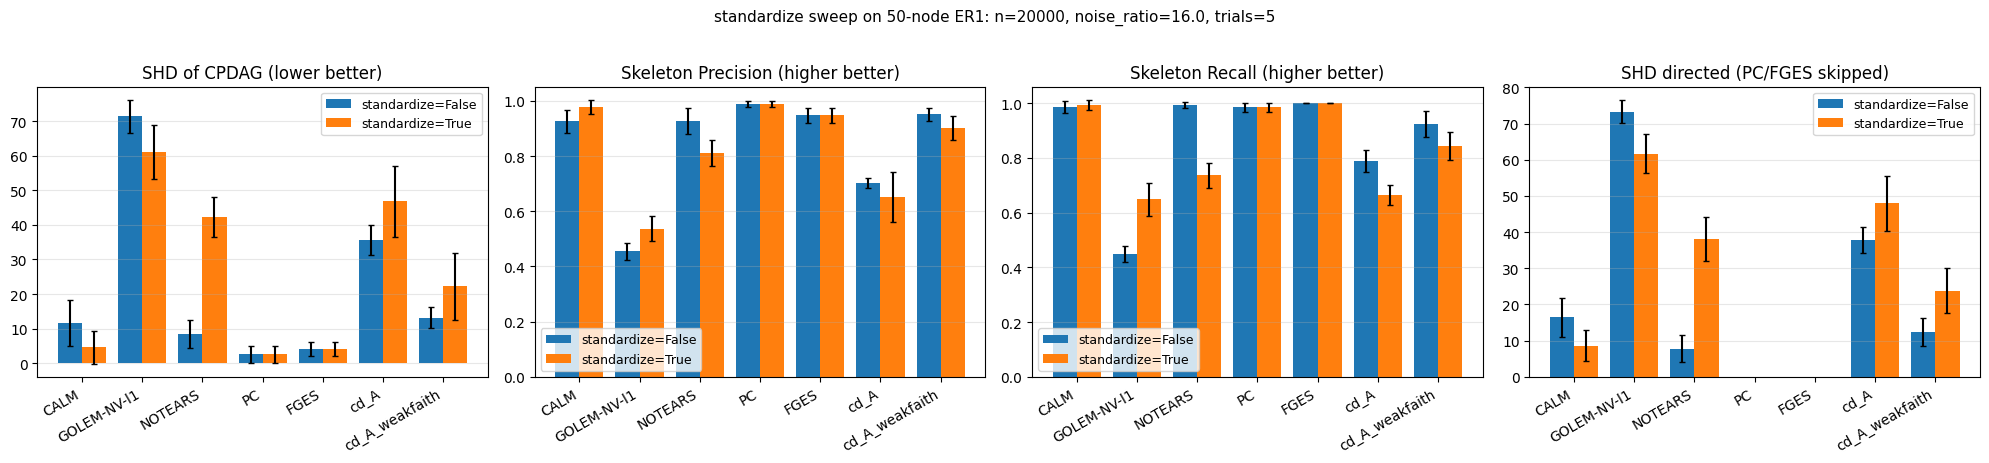

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
metrics_to_plot = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'SHD of CPDAG (lower better)'),
    ('sk_p_mean',      'sk_p_std',      'Skeleton Precision (higher better)'),
    ('sk_r_mean',      'sk_r_std',      'Skeleton Recall (higher better)'),
    ('shd_mean',       'shd_std',       'SHD directed (PC/FGES skipped)'),
]
x_pos = np.arange(len(ALGORITHM_ORDER))
n_groups = len(CFG['standardize_modes'])
width = 0.8 / max(n_groups, 1)

for ax, (mcol, scol, title) in zip(axes, metrics_to_plot):
    for gi, std_mode in enumerate(CFG['standardize_modes']):
        sub = df_summary[df_summary['standardize'] == std_mode].set_index('algorithm').reindex(ALGORITHM_ORDER)
        offset = (gi - (n_groups - 1) / 2) * width
        label = f'standardize={std_mode}'
        ax.bar(x_pos + offset, sub[mcol].values, width=width,
               yerr=sub[scol].values, label=label, capsize=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ALGORITHM_ORDER, rotation=30, ha='right')
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='y')
    ax.legend(fontsize=9)

fig.suptitle(
    f"standardize sweep on {_gc['label']}: "
    f"n={CFG['n_samples']}, noise_ratio={CFG['noise_ratio']}, trials={CFG['trials']}",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## 9. 失败/跳过记录

In [11]:
if skip_logs:
    df_skip = pd.DataFrame(skip_logs)
    display(df_skip)
else:
    print('所有 trial 均运行成功。')

所有 trial 均运行成功。
